In [9]:
from pathlib import Path

import duckdb

import geopandas as gpd

In [10]:
DATA_BASE_PATH = Path("./data").resolve().absolute()

In [11]:
porto_taxis_path = DATA_BASE_PATH / "porto_trajectories_all.parquet"
df = duckdb.query(f"SELECT * FROM '{porto_taxis_path}'").to_df()
df.head()

,taxi_id,trajectory_id,timestamp,source_point,target_point
0,20000589,1372636858620000589,2013-07-01 00:00:58,POINT(-8.618643 41.141412),POINT(-8.630838 41.154489)
1,20000596,1372637303620000596,2013-07-01 00:08:23,POINT(-8.639847 41.159826),POINT(-8.66574 41.170671)
2,20000320,1372636951620000320,2013-07-01 00:02:31,POINT(-8.612964 41.140359),POINT(-8.61597 41.14053)
3,20000520,1372636854620000520,2013-07-01 00:00:54,POINT(-8.574678 41.151951),POINT(-8.607996 41.142915)
4,20000337,1372637091620000337,2013-07-01 00:04:51,POINT(-8.645994 41.18049),POINT(-8.687268 41.178087)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1674160 entries, 0 to 1674159
Data columns (total 5 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   taxi_id        1674160 non-null  int64         
 1   trajectory_id  1674160 non-null  int64         
 2   timestamp      1674160 non-null  datetime64[us]
 3   source_point   1674160 non-null  object        
 4   target_point   1674160 non-null  object        
dtypes: datetime64[us](1), int64(2), object(2)
memory usage: 63.9+ MB


In [13]:
df.describe()

,taxi_id,trajectory_id,timestamp
count,1.674160e+06,1.674160e+06,1674160
mean,2.000035e+07,1.388600e+18,2014-01-01 18:19:49.389823
min,2.000000e+07,1.372637e+18,2013-07-01 00:00:53
25%,2.000017e+07,1.380707e+18,2013-10-02 09:36:09.250000
50%,2.000034e+07,1.388439e+18,2013-12-30 21:38:08
75%,2.000052e+07,1.396749e+18,2014-04-06 01:56:38.500000
max,2.000098e+07,1.404173e+18,2014-06-30 23:59:14
std,2.108922e+02,9.191939e+15,NaN


In [14]:
from shapely.wkt import loads

# Convert WKT strings to shapely geometries
df["source_geom"] = df["source_point"].apply(loads)
df["target_geom"] = df["target_point"].apply(loads)

In [15]:
gdf_source = gpd.GeoDataFrame(df, geometry="source_geom", crs="EPSG:4326")
gdf_target = gpd.GeoDataFrame(df, geometry="target_geom", crs="EPSG:4326")

In [16]:
from shapely.geometry import LineString

df["trajectory_line"] = df.apply(
    lambda row: LineString([row["source_geom"], row["target_geom"]]), axis=1
)
gdf_traj = gpd.GeoDataFrame(df, geometry="trajectory_line", crs="EPSG:4326")

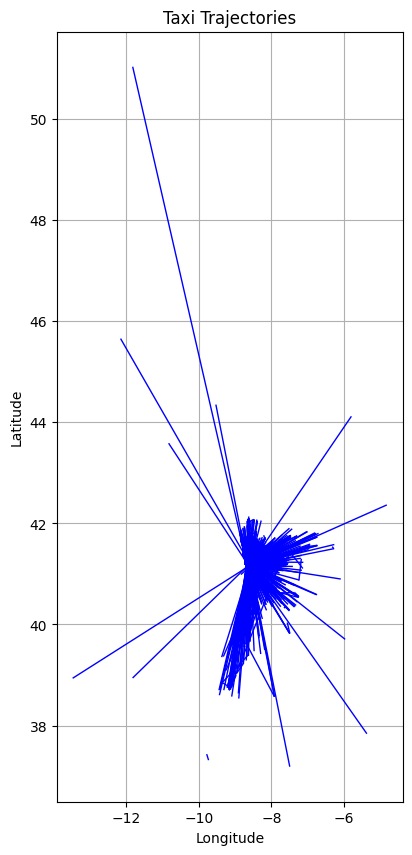

In [17]:
import matplotlib.pyplot as plt

# Plot all trajectory lines
gdf_traj.plot(figsize=(10, 10), color="blue", linewidth=1)

plt.title("Taxi Trajectories")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

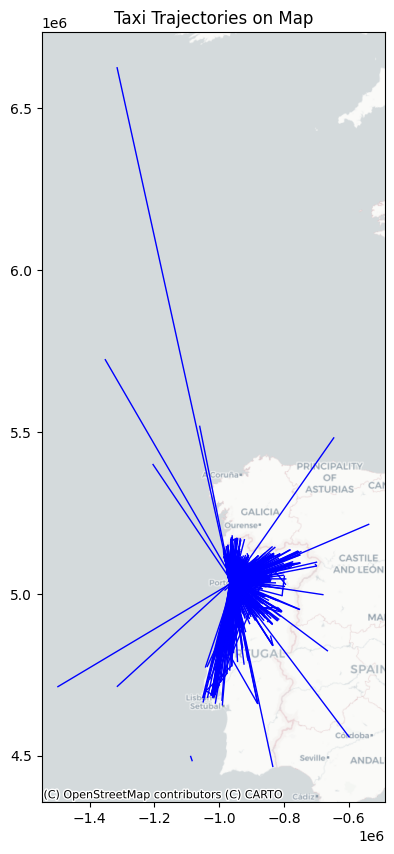

In [18]:
import contextily as ctx

# Convert to Web Mercator for plotting with tiles
gdf_traj_web = gdf_traj.to_crs(epsg=3857)

ax = gdf_traj_web.plot(figsize=(10, 10), color="blue", linewidth=1)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

plt.title("Taxi Trajectories on Map")
plt.show()

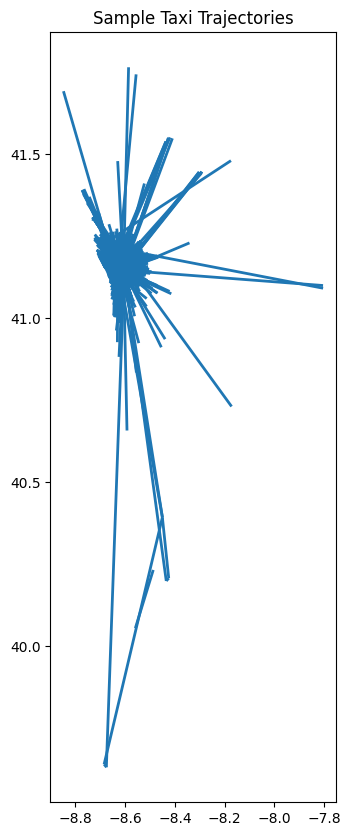

In [19]:
# Plot only a few taxis for clarity
sample = gdf_traj[gdf_traj["taxi_id"].isin([20000320, 20000520, 20000233])]

ax = sample.plot(figsize=(10, 10), linewidth=2)
plt.title("Sample Taxi Trajectories")
plt.show()